# 03 - Neural Network Comparison

Notebook 01 compares classical ML baselines and can tune their hyperparameters.

This notebook adds a neural network and evaluates it with the same Leave-One-AoA-Out strategy so the comparison is fair.


## 1. Imports

In [3]:
from pathlib import Path
import os
import sys

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

## 2. Connect The Notebook To The Project

In [4]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "cfd_ml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.cp import CP_FEATURES, load_cp_modeling_data, split_cp_features
from cfd_ml.evaluation import regression_metrics, summarize_regression_scores
from cfd_ml.paths import METRICS_DIR

tf.keras.utils.set_random_seed(42)
tf.get_logger().setLevel("ERROR")

print(PROJECT_ROOT)

/Users/pun/Desktop/CFD-ML/CFD-Machine-learning


## 3. Load Data

The neural network uses the same input features as Notebook 01:

- `x`, `y`
- `sin_AoA`, `cos_AoA`

The target is still `Pressure_Coefficient`.

In [5]:
cp_df = load_cp_modeling_data()
X, y, groups = split_cp_features(cp_df)

print("Rows:", len(cp_df))
print("Features:", CP_FEATURES)
print("AoA cases:", groups.nunique())

cp_df.head()

Rows: 4032
Features: ['x', 'y', 'sin_AoA', 'cos_AoA']
AoA cases: 21


,AoA,x,y,sin_AoA,cos_AoA,Pressure_Coefficient
0,0.0,0.985397,0.000943,0.0,1.0,0.262408
1,0.0,0.969573,0.001489,0.0,1.0,0.279663
2,0.0,0.952680,0.001679,0.0,1.0,0.293002
3,0.0,0.934996,0.001511,0.0,1.0,0.295781
4,0.0,0.916822,0.000923,0.0,1.0,0.292556


## 4. Load Tuned Classical Model Results

Notebook 01 tunes the classical ML models with the same Leave-One-AoA-Out validation strategy. This notebook loads the tuned summary and fold-level Random Forest results so the neural network is compared against the strongest classical model from Notebook 01.


In [6]:
tuned_summary_path = METRICS_DIR / "cp_tuned_model_comparison_summary.csv"
tuned_fold_path = METRICS_DIR / "cp_tuned_model_comparison_by_aoa.csv"
rf_reference_name = "Random forest tuned"

missing_paths = [
    path for path in [tuned_summary_path, tuned_fold_path]
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Run notebooks/01_cp_surrogate_model.ipynb through the tuning section first. "
        f"Missing: {[path.name for path in missing_paths]}"
    )

classical_summary = pd.read_csv(tuned_summary_path, index_col="model")
classical_scores = pd.read_csv(tuned_fold_path)

if rf_reference_name not in classical_summary.index:
    raise ValueError(f"{rf_reference_name!r} was not found in {tuned_summary_path.name}")

random_forest_scores = classical_scores[
    classical_scores["model"].eq(rf_reference_name)
].copy()

print(f"Loaded tuned classical summary: {tuned_summary_path.name}")
print(f"Loaded tuned fold scores: {tuned_fold_path.name}")
classical_summary


Loaded tuned classical summary: cp_tuned_model_comparison_summary.csv
Loaded tuned fold scores: cp_tuned_model_comparison_by_aoa.csv


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.028635,0.062083,0.982564,0.044351
Gradient boosting tuned,0.046010,0.074885,0.979126,0.040535
Polynomial ridge tuned,0.241918,0.338279,0.709052,0.039866


## 5. Build The Neural Network

The neural network is a multilayer perceptron. It can learn nonlinear relationships between airfoil surface location, angle of attack, and Cp.

We scale both inputs and target values inside each fold to avoid data leakage.

In [7]:
def build_cp_neural_network(input_dim):
    regularizer = tf.keras.regularizers.l2(1e-6)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(64, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
    )

## 6. Evaluate The Neural Network

This cell may take longer than the classical ML baselines because it trains one neural network per held-out AoA case.

In [8]:
def evaluate_neural_network(X, y, groups, epochs=120, batch_size=64):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []
    training_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        test_aoa = float(groups.iloc[test_idx].unique()[0])

        X_train = X.iloc[train_idx].to_numpy()
        X_test = X.iloc[test_idx].to_numpy()
        y_train = y.iloc[train_idx].to_numpy().reshape(-1, 1)
        y_test = y.iloc[test_idx].to_numpy()

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        y_train_scaled = scaler_y.fit_transform(y_train)

        model = build_cp_neural_network(input_dim=X_train_scaled.shape[1])
        history = model.fit(
            X_train_scaled,
            y_train_scaled,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[build_early_stopping()],
            verbose=0,
        )

        y_pred_scaled = model.predict(X_test_scaled, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

        metrics = regression_metrics(y_test, y_pred)
        metrics.update({"fold": fold, "AoA": test_aoa, "model": "Neural network"})
        fold_scores.append(metrics)

        prediction_frame = cp_df.iloc[test_idx][["AoA", "x", "y"]].copy()
        prediction_frame["y_true"] = y_test
        prediction_frame["y_pred"] = y_pred
        fold_predictions.append(prediction_frame)

        training_rows.append({
            "fold": fold,
            "AoA": test_aoa,
            "epochs_used": len(history.history["loss"]),
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history["val_loss"][-1],
        })

        print(
            f"AoA {test_aoa:>4.1f} | "
            f"RMSE {metrics['RMSE']:.4f} | "
            f"R2 {metrics['R2']:.4f} | "
            f"epochs {len(history.history['loss'])}"
        )

    return (
        pd.DataFrame(fold_scores),
        pd.concat(fold_predictions, ignore_index=True),
        pd.DataFrame(training_rows),
    )

In [9]:
nn_scores, nn_predictions, nn_training = evaluate_neural_network(X, y, groups)
nn_scores.head()

AoA  0.0 | RMSE 0.1410 | R2 0.8829 | epochs 95
AoA  1.0 | RMSE 0.0567 | R2 0.9856 | epochs 115
AoA  2.0 | RMSE 0.0751 | R2 0.9830 | epochs 91
AoA  3.0 | RMSE 0.1343 | R2 0.9621 | epochs 84
AoA  4.0 | RMSE 0.0978 | R2 0.9832 | epochs 96
AoA  5.0 | RMSE 0.0975 | R2 0.9841 | epochs 78
AoA  6.0 | RMSE 0.1092 | R2 0.9804 | epochs 61
AoA  7.0 | RMSE 0.0737 | R2 0.9911 | epochs 95
AoA  8.0 | RMSE 0.0742 | R2 0.9909 | epochs 91
AoA  9.0 | RMSE 0.1374 | R2 0.9671 | epochs 40
AoA 10.0 | RMSE 0.0849 | R2 0.9860 | epochs 120
AoA 11.0 | RMSE 0.0994 | R2 0.9778 | epochs 65
AoA 12.0 | RMSE 0.0789 | R2 0.9849 | epochs 89
AoA 13.0 | RMSE 0.1105 | R2 0.9693 | epochs 42
AoA 14.0 | RMSE 0.0837 | R2 0.9820 | epochs 95
AoA 15.0 | RMSE 0.0802 | R2 0.9836 | epochs 89
AoA 16.0 | RMSE 0.0962 | R2 0.9767 | epochs 74
AoA 17.0 | RMSE 0.0917 | R2 0.9795 | epochs 71
AoA 18.0 | RMSE 0.0938 | R2 0.9790 | epochs 65
AoA 19.0 | RMSE 0.0897 | R2 0.9812 | epochs 81
AoA 20.0 | RMSE 0.1444 | R2 0.9531 | epochs 45


,MAE,RMSE,R2,fold,AoA,model
0,0.118841,0.141005,0.882867,1,0.0,Neural network
1,0.044066,0.056695,0.985600,2,1.0,Neural network
2,0.059417,0.075121,0.983049,3,2.0,Neural network
3,0.106288,0.134332,0.962064,4,3.0,Neural network
4,0.074248,0.097815,0.983155,5,4.0,Neural network


## 7. Compare Neural Network Against Tuned Random Forest

The main comparison is against `Random forest tuned`, because Notebook 01 identified it as the strongest classical Cp surrogate.


In [10]:
nn_summary = summarize_regression_scores(nn_scores)
comparison_summary = pd.concat([classical_summary, nn_summary]).sort_values("RMSE_mean")

rf_nn_summary = comparison_summary.loc[[rf_reference_name, "Neural network"]].copy()
rf_rmse = rf_nn_summary.loc[rf_reference_name, "RMSE_mean"]
nn_rmse = rf_nn_summary.loc["Neural network", "RMSE_mean"]

rf_nn_takeaway = pd.DataFrame([{
    "reference_model": rf_reference_name,
    "neural_network_RMSE": nn_rmse,
    "random_forest_RMSE": rf_rmse,
    "RMSE_gap_NN_minus_RF": nn_rmse - rf_rmse,
    "NN_RMSE_percent_higher": ((nn_rmse / rf_rmse) - 1) * 100,
    "winner": "Neural network" if nn_rmse < rf_rmse else rf_reference_name,
}])

rf_vs_nn_by_aoa = (
    nn_scores[["fold", "AoA", "MAE", "RMSE", "R2"]]
    .rename(columns={
        "MAE": "NN_MAE",
        "RMSE": "NN_RMSE",
        "R2": "NN_R2",
    })
    .merge(
        random_forest_scores[["AoA", "MAE", "RMSE", "R2"]].rename(columns={
            "MAE": "RF_MAE",
            "RMSE": "RF_RMSE",
            "R2": "RF_R2",
        }),
        on="AoA",
        how="inner",
    )
    .sort_values("AoA")
)
rf_vs_nn_by_aoa["RMSE_gap_NN_minus_RF"] = (
    rf_vs_nn_by_aoa["NN_RMSE"] - rf_vs_nn_by_aoa["RF_RMSE"]
)
rf_vs_nn_by_aoa["winner"] = np.where(
    rf_vs_nn_by_aoa["NN_RMSE"] < rf_vs_nn_by_aoa["RF_RMSE"],
    "Neural network",
    rf_reference_name,
)

display(comparison_summary)
display(rf_nn_summary)
display(rf_vs_nn_by_aoa)
rf_nn_takeaway


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.028635,0.062083,0.982564,0.044351
Gradient boosting tuned,0.046010,0.074885,0.979126,0.040535
Neural network,0.065741,0.097637,0.974443,0.024215
Polynomial ridge tuned,0.241918,0.338279,0.709052,0.039866


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.028635,0.062083,0.982564,0.044351
Neural network,0.065741,0.097637,0.974443,0.024215


,fold,AoA,NN_MAE,NN_RMSE,NN_R2,RF_MAE,RF_RMSE,RF_R2,RMSE_gap_NN_minus_RF,winner
0,1,0.0,0.118841,0.141005,0.882867,0.145368,0.183921,0.800717,-0.042915,Neural network
1,2,1.0,0.044066,0.056695,0.985600,0.019626,0.030954,0.995708,0.025741,Random forest tuned
2,3,2.0,0.059417,0.075121,0.983049,0.024776,0.037959,0.995672,0.037162,Random forest tuned
3,4,3.0,0.106288,0.134332,0.962064,0.036057,0.059193,0.992634,0.075139,Random forest tuned
4,5,4.0,0.074248,0.097815,0.983155,0.036629,0.062053,0.993221,0.035762,Random forest tuned
5,6,5.0,0.059780,0.097546,0.984106,0.025917,0.076453,0.990236,0.021093,Random forest tuned
6,7,6.0,0.074737,0.109166,0.980437,0.029889,0.085161,0.988095,0.024005,Random forest tuned
7,8,7.0,0.045322,0.073653,0.991122,0.031730,0.092471,0.986005,-0.018819,Neural network
8,9,8.0,0.045006,0.074219,0.990886,0.036954,0.106205,0.981337,-0.031986,Neural network
9,10,9.0,0.097091,0.137385,0.967078,0.041695,0.112405,0.977962,0.024980,Random forest tuned


,reference_model,neural_network_RMSE,random_forest_RMSE,RMSE_gap_NN_minus_RF,NN_RMSE_percent_higher,winner
0,Random forest tuned,0.097637,0.062083,0.035553,57.267402,Random forest tuned


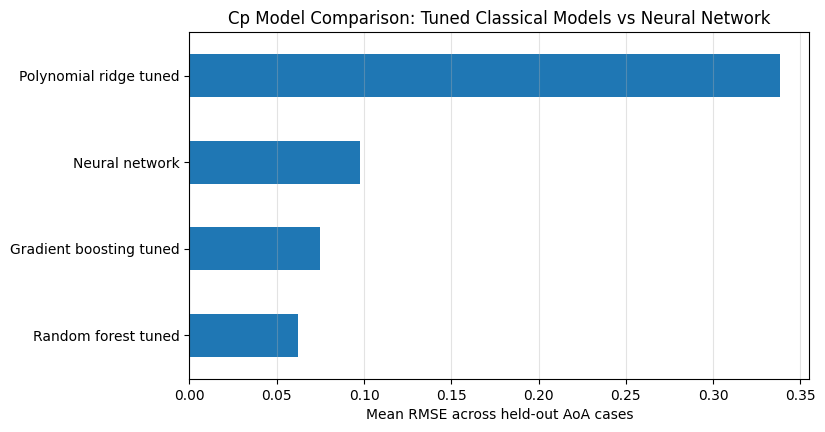

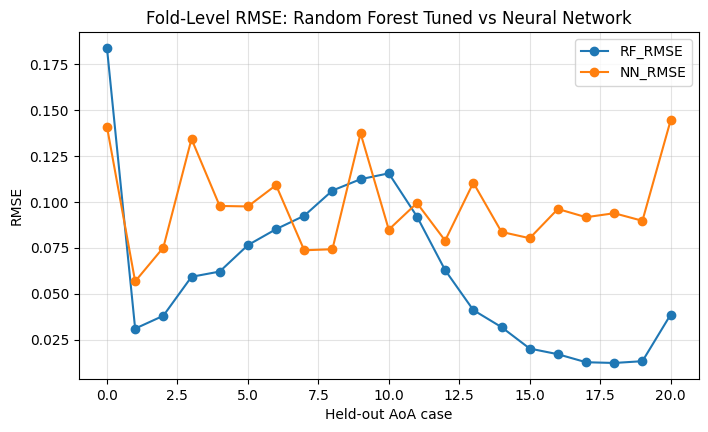

In [11]:
ax = comparison_summary["RMSE_mean"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 4.5),
)
ax.set_xlabel("Mean RMSE across held-out AoA cases")
ax.set_ylabel("")
ax.set_title("Cp Model Comparison: Tuned Classical Models vs Neural Network")
ax.grid(True, axis="x", alpha=0.35)
plt.show()

ax = rf_vs_nn_by_aoa.plot(
    x="AoA",
    y=["RF_RMSE", "NN_RMSE"],
    marker="o",
    figsize=(8, 4.5),
)
ax.set_xlabel("Held-out AoA case")
ax.set_ylabel("RMSE")
ax.set_title("Fold-Level RMSE: Random Forest Tuned vs Neural Network")
ax.grid(True, alpha=0.35)
plt.show()

## 8. Inspect Neural Network Predictions

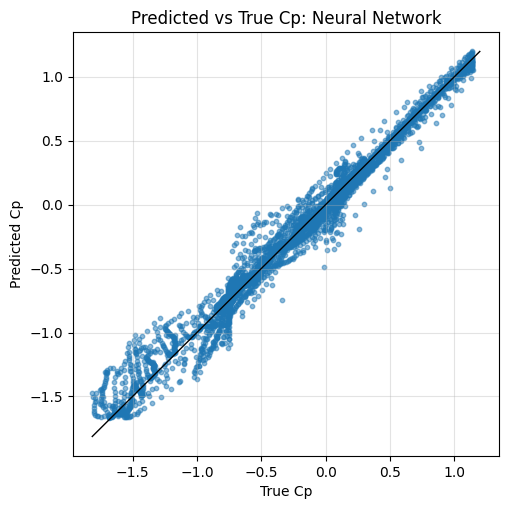

In [12]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(nn_predictions["y_true"], nn_predictions["y_pred"], s=10, alpha=0.5)

min_value = min(nn_predictions["y_true"].min(), nn_predictions["y_pred"].min())
max_value = max(nn_predictions["y_true"].max(), nn_predictions["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)

plt.xlabel("True Cp")
plt.ylabel("Predicted Cp")
plt.title("Predicted vs True Cp: Neural Network")
plt.grid(True, alpha=0.35)
plt.show()

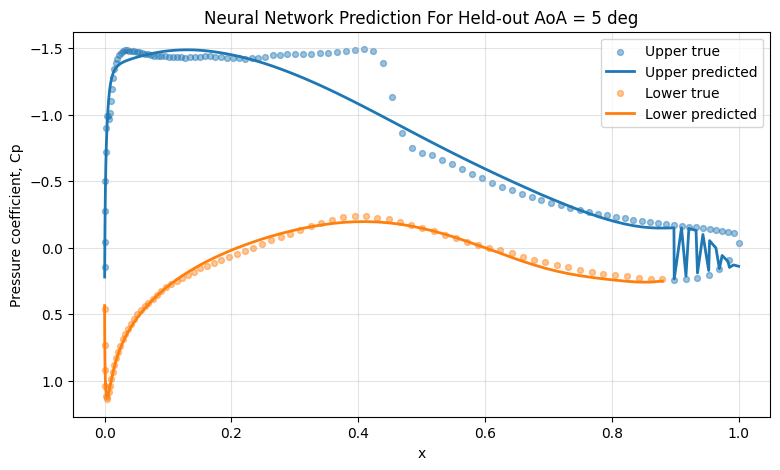

In [13]:
def plot_nn_prediction_for_aoa(predictions, aoa):
    case = predictions[predictions["AoA"] == aoa].copy()
    if case.empty:
        raise ValueError(f"AoA {aoa} not found in predictions")

    upper = case[case["y"] > 0].sort_values("x")
    lower = case[case["y"] <= 0].sort_values("x")

    plt.figure(figsize=(9, 5))
    plt.scatter(upper["x"], upper["y_true"], s=18, alpha=0.45, label="Upper true")
    plt.plot(upper["x"], upper["y_pred"], linewidth=2, label="Upper predicted")
    plt.scatter(lower["x"], lower["y_true"], s=18, alpha=0.45, label="Lower true")
    plt.plot(lower["x"], lower["y_pred"], linewidth=2, label="Lower predicted")

    plt.gca().invert_yaxis()
    plt.xlabel("x")
    plt.ylabel("Pressure coefficient, Cp")
    plt.title(f"Neural Network Prediction For Held-out AoA = {aoa:g} deg")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.show()


plot_nn_prediction_for_aoa(nn_predictions, aoa=5.0)

## 9. Save Neural Network Metrics

In [14]:
METRICS_DIR.mkdir(parents=True, exist_ok=True)

comparison_summary_path = METRICS_DIR / "cp_nn_comparison_summary.csv"
rf_nn_takeaway_path = METRICS_DIR / "cp_nn_vs_random_forest_summary.csv"
rf_vs_nn_by_aoa_path = METRICS_DIR / "cp_nn_vs_random_forest_by_aoa.csv"
nn_scores_path = METRICS_DIR / "cp_nn_scores_by_aoa.csv"
nn_training_path = METRICS_DIR / "cp_nn_training_by_aoa.csv"

comparison_summary.to_csv(comparison_summary_path)
rf_nn_takeaway.to_csv(rf_nn_takeaway_path, index=False)
rf_vs_nn_by_aoa.to_csv(rf_vs_nn_by_aoa_path, index=False)
nn_scores.to_csv(nn_scores_path, index=False)
nn_training.to_csv(nn_training_path, index=False)

print(comparison_summary_path)
print(rf_nn_takeaway_path)
print(rf_vs_nn_by_aoa_path)
print(nn_scores_path)
print(nn_training_path)

/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_nn_comparison_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_nn_vs_random_forest_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_nn_vs_random_forest_by_aoa.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_nn_scores_by_aoa.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_nn_training_by_aoa.csv


## Conclusion

The neural network is compared directly against the tuned Random Forest from Notebook 01 using the same Leave-One-AoA-Out folds.

If the neural network beats `Random forest tuned`, it is justified as the stronger Cp surrogate. If tuned Random Forest still wins, that is also a useful ML conclusion: for this small tabular CFD dataset, tree ensembles may generalize better than the fixed neural-network architecture.